# Anomaly Detection

An out-of-distribution check, sitting alongside the risk model rather than inside it.

The two answer different questions:

| | Question |
|---|---|
| **Risk model** | Does this look like the contracts we *defined* as high attention? |
| **This check** | Does this look like **anything we have seen before**? |

A contract can score low on the first and still fail the second — an unfamiliar shape the model has
no basis to judge. A low score there is not evidence of low risk; it means the model was asked about
something unlike its training data, and a confident answer is worth less than no answer. So the brief
requires such a record to become `HIGH_ATTENTION`, never `ROUTINE`.

### Why the Part 3 leakage rules do not apply here

Part 3 had to withhold amount and method because the *label* was computable from them, so a
supervised model trained on them learned a tautology. **This detector is unsupervised — it never sees
the label** — so there is no target to leak into.

It therefore uses the full feature set including amount and method. That is not merely permitted, it
is necessary: the brief's own example of a good explanation is *"an unusually high amount relative to
the category median... a non-competitive procurement method not seen frequently in this region"* —
precisely the features Part 3 had to exclude.

In [1]:
import sys, warnings
from pathlib import Path
# Resolve the repo root by walking up until the package is found, rather than
# assuming the kernel's working directory is notebooks/. Opening this notebook
# from the repo root would otherwise fail on this very first line.
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "procurement_risk").exists())
sys.path.insert(0, str(REPO / "src"))
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 210); pd.set_option("display.max_colwidth", 120)

from procurement_risk import config, model as M, anomaly as A
from procurement_risk.rules import Cohort

eligible = pd.read_parquet(config.DATA_DIR / "model_eligible.parquet")
splits = M.split_by_fiscal_year(eligible)
detector = A.fit_detector(splits["train"])
print(f"Isolation Forest fitted on {len(splits['train']):,} training-year records")
print(f"features ({len(detector.columns)}): {detector.columns}")

Isolation Forest fitted on 115,957 training-year records
features (13): ['log_amount', 'amount_vs_category_region_median', 'amount_percentile_in_category_region', 'amount_vs_practice_median', 'supplier_prior_contract_count', 'project_contract_sequence', 'days_into_fiscal_year', 'consortium_size', 'benchmark_support_n', 'is_competitive_method', 'supplier_is_domestic', 'is_first_contract_in_project', 'supplier_in_secrecy_jurisdiction']


## 1. Fitted on the training years only

The brief says to train on model-assessment-eligible records. Restricting further to the *training*
fiscal years keeps the discipline used everywhere else in the pipeline: "unusual relative to the
training population" is only meaningful if that population predates what is being judged. Otherwise
a contract helps define the distribution it is then measured against.

`contamination` is set to 1%, calibrated on reviewable volume like every other threshold here —
these records get promoted to `HIGH_ATTENTION`, so the flag has to stay rare enough to mean something.

In [2]:
rows = []
for name in ("train", "validate", "test", "quarantined"):
    part = splits[name]
    flag = detector.is_anomalous(part)
    y = M.build_target(part)
    rows.append({"split": name, "n": len(part), "flagged": int(flag.sum()),
                 "flagged_%": round(float(flag.mean())*100, 2),
                 "high-attention rate among flagged": round(float(y[flag].mean()), 3),
                 "base rate": round(float(y.mean()), 3)})
pd.DataFrame(rows)

,split,n,flagged,flagged_%,high-attention rate among flagged,base rate
0,train,115957,1159,1.00,0.228,0.042
1,validate,42950,589,1.37,0.165,0.032
2,test,120238,3930,3.27,0.142,0.033
3,quarantined,1139,206,18.09,0.141,0.064


Two things worth reading off that table.

**The flag rate rises over time** — 1.00% on the training years, 3.27% on the test years. That is not
a defect, it is the finding: the portfolio drifts away from the distribution the detector was fitted
on. An out-of-distribution check that *didn't* show this would be the suspicious one. FY2027 flags
18% because it is a seven-week stub whose composition is skewed toward large prior-review contracts.

**Flagged contracts are 4–5x enriched in high attention** without the detector ever seeing the label.
It is finding something real, not noise — though note the enrichment is a side effect, not the
purpose. The point of this check is the contracts the *model* scores low.

## 2. Explanations — templated, not generated

Every flagged record gets a one-sentence explanation built from its own feature values, by comparing
each against the training distribution and naming the two most extreme.

**Deliberately deterministic.** A procurement decision has to be reproducible: the same contract must
produce the same sentence today and at an audit two years from now, traceable to the values that
caused it. A generated sentence that varied between runs would break the audit record for no gain in
accuracy — this is a place where *not* using a language model is the engineering decision.

At most one phrase per feature family, so a sentence names two different kinds of unusual rather than
saying "a large amount, combined with a large amount".

In [3]:
te = splits["test"]
flag = detector.is_anomalous(te)
anoms = te[flag]
rng = np.random.default_rng(1)
for i in rng.choice(len(anoms), 8, replace=False):
    r = anoms.iloc[i]
    print(f"[${r.amount_usd:>12,.0f} | {r.procurement_category:<24}| {r.procurement_method_raw}]")
    print(f"   {detector.describe(r)}\n")

[$     530,660 | Goods                   | Request for Quotations]
   This contract is unusual for its training population: it has an amount at the top of its peer group, combined with signing unusually late in the fiscal year.

[$   6,061,540 | Works                   | Request for Bids]
   This contract is unusual for its training population: it has an amount far above the median for its global practice.

[$       5,460 | Consultant Services     | Direct Selection]
   This contract is unusual for its training population: it has a supplier foreign to the borrower country, combined with a non-competitive procurement method.

[$   2,166,000 | Goods                   | Request for Bids]
   This contract is unusual for its training population: it has an amount far above the median for its category and region, combined with a supplier foreign to the borrower country.

[$     571,555 | Consultant Services     | Direct Selection]
   This contract is unusual for its training population: it ha

### 2.1 A defect worth recording

The first version of this reported **"a single-supplier award"** as the most unusual feature of
almost every flagged contract — which is absurd, since 93% of contracts have a single supplier.

The cause: `np.searchsorted` defaults to `side="left"`, which counts values *strictly less than* the
input. A value shared by most of the population therefore lands at percentile 0 and reads as
maximally extreme. Taking the midpoint of the tied range fixes it.

It is a good example of why explanations need checking against intuition rather than just running.
The sentences were fluent, plausible and completely wrong, and no test of the *detector* would have
caught it — only reading the output did.

In [4]:
ref = detector.reference["consortium_size"]
lo = np.searchsorted(ref, 1.0, side="left"); hi = np.searchsorted(ref, 1.0, side="right")
print(f"consortium_size == 1 is {float((hi-lo)/len(ref))*100:.1f}% of the training population")
print(f"  percentile, side='left'   : {lo/len(ref):.3f}  -> extremity {abs(lo/len(ref)-0.5)*2:.3f}  (the bug)")
print(f"  percentile, tied midpoint : {((lo+hi)/2)/len(ref):.3f}  -> extremity {abs(((lo+hi)/2)/len(ref)-0.5)*2:.3f}  (correct)")

consortium_size == 1 is 92.5% of the training population
  percentile, side='left'   : 0.000  -> extremity 1.000  (the bug)
  percentile, tied midpoint : 0.462  -> extremity 0.075  (correct)


## 3. The override the brief requires

> *A contract that receives a low risk score but is flagged as anomalous should be classified as high
> attention, not routine.*

`apply_anomaly_override` only ever moves a record **up** the precedence order. It never rescues one
the rules already stopped, and never downgrades `EXCEPTIONAL` or `NOT_ELIGIBLE`.

In [5]:
for c in (Cohort.ROUTINE, Cohort.HIGH_ATTENTION, Cohort.EXCEPTIONAL, Cohort.NOT_ELIGIBLE):
    print(f"  {str(c):<15} + anomaly -> {str(A.apply_anomaly_override(c, True))}")

  ROUTINE         + anomaly -> HIGH_ATTENTION
  HIGH_ATTENTION  + anomaly -> HIGH_ATTENTION
  EXCEPTIONAL     + anomaly -> EXCEPTIONAL
  NOT_ELIGIBLE    + anomaly -> NOT_ELIGIBLE


In [6]:
# How many contracts does the override actually rescue from ROUTINE?
gbt = M.train(splits["train"], splits["validate"], kind="gbt")
yva = M.build_target(splits["validate"])
gbt.threshold = M.choose_threshold(yva, gbt.predict_proba(splits["validate"]), min_recall=0.90)

scores = gbt.predict_proba(te)
low_risk = scores < gbt.threshold
promoted = low_risk & flag

print(f"test-year contracts scored below the model threshold : {int(low_risk.sum()):>7,}")
print(f"  ...of which flagged as out-of-distribution         : {int(promoted.sum()):>7,}"
      f"  ({promoted.mean()*100:.2f}% of all test records)")
y = M.build_target(te)
print(f"\nhigh-attention rate among those promoted            : {float(y[promoted].mean()):.3f}")
print(f"high-attention rate among low-risk NOT promoted     : {float(y[low_risk & ~flag].mean()):.3f}")

test-year contracts scored below the model threshold :  77,937
  ...of which flagged as out-of-distribution         :   1,991  (1.66% of all test records)

high-attention rate among those promoted            : 0.025
high-attention rate among low-risk NOT promoted     : 0.007


That last comparison is the justification for the override existing at all. Among contracts the model
scores as low risk, the ones the detector flags are several times more likely to be high attention
than the ones it does not. The model was wrong about them in a way it had no means of knowing — which
is precisely what an out-of-distribution check is for.

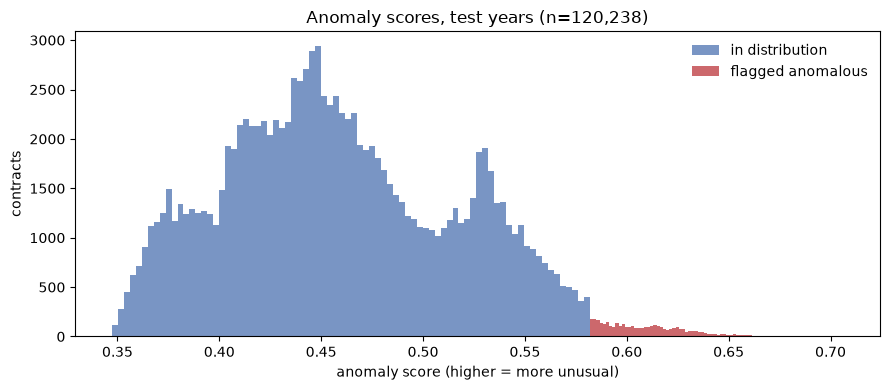

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
s = detector.score(te)
ax.hist(s[~flag], bins=80, alpha=.75, label="in distribution", color="#4C72B0")
ax.hist(s[flag], bins=80, alpha=.85, label="flagged anomalous", color="#C44E52")
ax.set(xlabel="anomaly score (higher = more unusual)", ylabel="contracts",
       title=f"Anomaly scores, test years (n={len(te):,})")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 4. Limitations

- **Unsupervised, so "unusual" is not "wrong".** Most flagged contracts will be perfectly proper —
  a genuinely novel but legitimate procurement looks identical to a problematic one from here. This
  routes attention; it does not make findings.
- **The contamination rate is a choice, not a discovery.** 1% is calibrated on reviewer capacity.
  Isolation Forest has no natural threshold, and nothing in the data says where the line belongs.
- **Drift makes the flag rate non-stationary.** 1% on training years becomes 3.27% on test years, so
  a fixed contamination silently means a growing queue. A deployed version needs the detector
  refitted on a schedule, with the rate monitored as an alarm in its own right.
- **Explanations describe, they do not diagnose.** The sentence says which feature values are
  unusual, not why that matters — a reviewer still supplies the judgment.
- **Missing values are handled with a sentinel** (`-999`) rather than imputation, keeping "unknown"
  separable. But a record with several missing features may be flagged for its *missingness pattern*
  rather than its contract characteristics, which is worth knowing when reading an explanation.